# HW 2

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp


## Problem 1

In [9]:
#nieve way to evaluate polynomial
x1,x2,y1,y2 = 1.92, 2.08, -1.5e-10, 1.5e-10
N = 20
points_x = [x1]
points_y = []
roots = 2
p = [1,-18,144,-672,2016,-4032,5376,-4608,2304,-512]
power = 9
eqidist = (x2 - x1) / (N-1)

for i in range(1,N-1):
    points_x.append((x1 + i*eqidist))
points_x.append(x2)

for j in range(len(points_x)):
    for s in range(len(p)):
        if s == 0:
            points_y.append(p[s]*points_x[j]**power)
        else:
            points_y[j] = points_y[j] + p[s]*points_x[j]**(power - s)



In [10]:
#condensed way to evaluate polynomial
def f(x):
    return (x-2)**9

p1 = []
for x in points_x:
    p1.append(f(x))



In [11]:
# Horner's Rule
p2 = []
def c(x):
    return (((((((((x-18)* x + 144)* x - 672)*x + 2016)*x - 4032)
                    *x + 5376)*x -4608)*x + 2304)*x -512)

for x in points_x:
    p2.append(c(x))



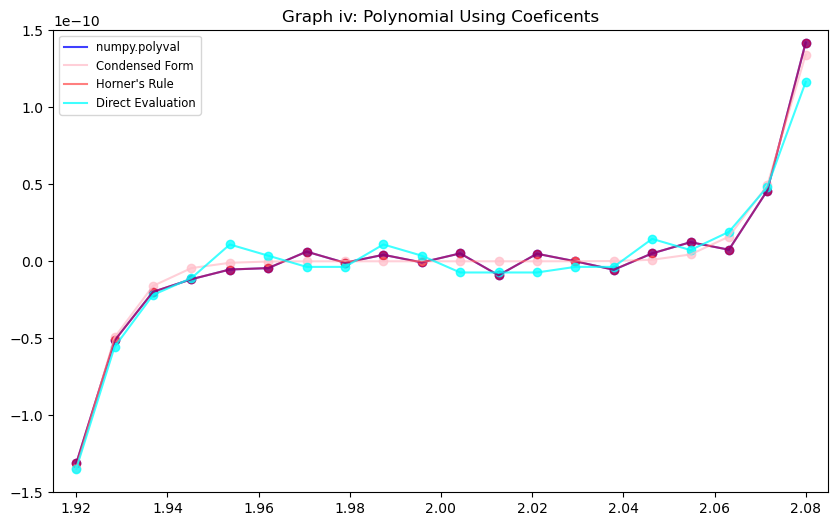

In [14]:
# numpy polyval
x1,x2,y1,y2 = 1.92, 2.08, -1.5e-10, 1.5e-10
N = 20
points_x = [x1]
p3 = []
roots = 2
p = np.poly1d([1,-18,144,-672,2016,-4032,5376,-4608,2304,-512])
eqidist = (x2 - x1) / (N-1)

for i in range(1,N-1):
    points_x.append((x1 + i*eqidist))
points_x.append(x2)

for j in range(len(points_x)):
    p3.append(np.polyval(p, points_x[j]))

plt.figure(figsize=(10,6))
plt.title('Graph iv: Polynomial Using Coeficents')
plt.axis([x1-0.005, x2+0.005, y1, y2])
plt.scatter(points_x, p3, color='blue',alpha=0.75)
plt.plot(points_x, p3, color='blue',alpha=0.75, label='numpy.polyval')
plt.scatter(points_x, p1, color='pink',alpha=0.75)
plt.plot(points_x, p1, color='pink',alpha=0.75, label='Condensed Form')
plt.plot(points_x, p2, color='red',alpha=0.5, label='Horner\'s Rule')
plt.scatter(points_x, p2, color='red',alpha=0.5)
plt.scatter(points_x, points_y, color='cyan',alpha=0.75)
plt.plot(points_x, points_y, color='cyan',alpha=0.75, label='Direct Evaluation')
plt.legend(loc='upper left', fontsize='small')
plt.show()